
# ml_07_text_and_image_femi.ipynb

## Technical Modification: Text and Image Result Analysis

This notebook applies new skills to analyze text and image service results in a structured way.

- Author: Oluwafemi Salawu
- Date: 2026-08-03
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

This notebook:

- stores API-style JSON responses in Python dictionaries
- flattens image label JSON into DataFrames
- compares good, incomplete, and interesting image results
- summarizes confidence values
- creates visuals from image label and text sentiment results
- saves charts to docs/images/
- logs the run to the root project.log


In [9]:
from __future__ import annotations

from importlib.metadata import PackageNotFoundError, version
import logging
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [10]:
NOTEBOOK_NAME = "ml_07_text_and_image_femi.ipynb"

# Make the notebook work whether it is launched from the project root or notebooks/
CWD = Path.cwd()
ROOT_DIR = CWD.parent if CWD.name == "notebooks" else CWD
PROJECT_LOG = ROOT_DIR / "project.log"
IMAGE_DIR = ROOT_DIR / "docs" / "images"
DATA_DIR = ROOT_DIR / "data" / "processed"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

LOG = logging.getLogger("M07")
LOG.setLevel(logging.DEBUG)
LOG.propagate = False

# Clear existing handlers so repeated notebook runs do not duplicate log lines.
for handler in list(LOG.handlers):
    LOG.removeHandler(handler)
    handler.close()

formatter = logging.Formatter(
    fmt="%(asctime)s | %(levelname)s | M07 | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

file_handler = logging.FileHandler(PROJECT_LOG, mode="a", encoding="utf-8")
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)
LOG.addHandler(file_handler)

stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setLevel(logging.INFO)
stream_handler.setFormatter(formatter)
LOG.addHandler(stream_handler)


def package_version(package_name: str) -> str:
    """Return installed package version or NOT INSTALLED."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "NOT INSTALLED"


LOG.info("========================")
LOG.info("=== RUN START ===")
LOG.info("project=M07")
LOG.info(f"repo_dir={ROOT_DIR.name}")
LOG.info(f"notebook={NOTEBOOK_NAME}")
LOG.info(f"python={platform.python_version()}")
LOG.info(f"os={platform.system()} {platform.release()}")
LOG.info("shell=notebook")
LOG.info(f"cwd={Path.cwd()}")
LOG.info(f"project_log={PROJECT_LOG}")
LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {package_version('pandas')}")
LOG.info(f"  numpy:        {package_version('numpy')}")
LOG.info(f"  matplotlib:   {package_version('matplotlib')}")
LOG.info(f"  seaborn:      {package_version('seaborn')}")
LOG.info(f"  requests:     {package_version('requests')}")
LOG.info("========================")

print(f"Project log path: {PROJECT_LOG}")

2026-08-03 18:01:11 | INFO | M07 | ========================
2026-08-03 18:01:11 | INFO | M07 | === RUN START ===
2026-08-03 18:01:11 | INFO | M07 | project=M07
2026-08-03 18:01:11 | INFO | M07 | repo_dir=ml-07-applied
2026-08-03 18:01:11 | INFO | M07 | notebook=ml_07_text_and_image_femi.ipynb
2026-08-03 18:01:11 | INFO | M07 | python=3.14.2
2026-08-03 18:01:11 | INFO | M07 | os=Windows 11
2026-08-03 18:01:11 | INFO | M07 | shell=notebook
2026-08-03 18:01:11 | INFO | M07 | cwd=c:\Repos\ml-07-applied\notebooks
2026-08-03 18:01:11 | INFO | M07 | project_log=c:\Repos\ml-07-applied\project.log
2026-08-03 18:01:11 | INFO | M07 | Confirming installation:
2026-08-03 18:01:11 | INFO | M07 |   python:       3.14.2
2026-08-03 18:01:11 | INFO | M07 |   pandas:       3.0.5
2026-08-03 18:01:11 | INFO | M07 |   numpy:        2.5.1
2026-08-03 18:01:11 | INFO | M07 |   matplotlib:   3.11.1
2026-08-03 18:01:11 | INFO | M07 |   seaborn:      0.13.2
2026-08-03 18:01:11 | INFO | M07 |   requests:     2.34.

## 1. Create JSON-style image service results

In [11]:
LOG.info("Creating JSON-style image analysis records")

image_results = [
    {
        "image_name": "good_match_puppies",
        "assessment_type": "good_match",
        "labels": [
            {"Name": "Animal", "Confidence": 99.9982},
            {"Name": "Canine", "Confidence": 99.9982},
            {"Name": "Dog", "Confidence": 99.9982},
            {"Name": "Pet", "Confidence": 99.9982},
            {"Name": "Puppy", "Confidence": 99.9982},
            {"Name": "Golden Retriever", "Confidence": 99.7147},
            {"Name": "Grass", "Confidence": 96.7513},
        ],
        "human_review": "The service correctly detected the puppies and grassy outdoor setting.",
    },
    {
        "image_name": "incomplete_duck_rabbit",
        "assessment_type": "not_good_match",
        "labels": [
            {"Name": "Art", "Confidence": 99.2553},
            {"Name": "Drawing", "Confidence": 96.2581},
            {"Name": "Animal", "Confidence": 90.4772},
            {"Name": "Bird", "Confidence": 90.4772},
            {"Name": "Face", "Confidence": 61.3857},
            {"Name": "Head", "Confidence": 61.3857},
            {"Name": "Person", "Confidence": 61.3857},
        ],
        "human_review": "The service detected the drawing and bird interpretation but missed the rabbit interpretation.",
    },
    {
        "image_name": "interesting_robot",
        "assessment_type": "interesting",
        "labels": [
            {"Name": "Robot", "Confidence": 99.9995},
            {"Name": "Accessories", "Confidence": 87.8310},
            {"Name": "Jewelry", "Confidence": 87.8310},
            {"Name": "Necklace", "Confidence": 87.8310},
            {"Name": "Person", "Confidence": 86.6008},
            {"Name": "Clothing", "Confidence": 62.3733},
            {"Name": "Glove", "Confidence": 62.3733},
        ],
        "human_review": "The service correctly detected robot but also labeled it as person because it is human-like.",
    },
]

LOG.info(f"Image result records: {len(image_results)}")

2026-08-03 18:01:11 | INFO | M07 | Creating JSON-style image analysis records
2026-08-03 18:01:11 | INFO | M07 | Image result records: 3


## 2. Flatten image JSON into a DataFrame

In [12]:
image_rows: list[dict[str, object]] = []

for result in image_results:
    for label in result["labels"]:
        row = {
            "image_name": result["image_name"],
            "assessment_type": result["assessment_type"],
            "label": label["Name"],
            "confidence": label["Confidence"],
            "human_review": result["human_review"],
        }
        image_rows.append(row)

image_df = pd.DataFrame(image_rows)
image_output = DATA_DIR / "ml_07_text_image_femi_image_labels.csv"
image_df.to_csv(image_output, index=False)

LOG.info("Flattened image JSON-style results")
LOG.info(f"Image label rows: {len(image_df)}")
LOG.info(f"Saved image label results to: {image_output}")

image_df

2026-08-03 18:01:12 | INFO | M07 | Flattened image JSON-style results
2026-08-03 18:01:12 | INFO | M07 | Image label rows: 21
2026-08-03 18:01:12 | INFO | M07 | Saved image label results to: c:\Repos\ml-07-applied\data\processed\ml_07_text_image_femi_image_labels.csv


,image_name,assessment_type,label,confidence,human_review
0,good_match_puppies,good_match,Animal,99.9982,The service correctly detected the puppies and...
1,good_match_puppies,good_match,Canine,99.9982,The service correctly detected the puppies and...
2,good_match_puppies,good_match,Dog,99.9982,The service correctly detected the puppies and...
3,good_match_puppies,good_match,Pet,99.9982,The service correctly detected the puppies and...
4,good_match_puppies,good_match,Puppy,99.9982,The service correctly detected the puppies and...
5,good_match_puppies,good_match,Golden Retriever,99.7147,The service correctly detected the puppies and...
6,good_match_puppies,good_match,Grass,96.7513,The service correctly detected the puppies and...
7,incomplete_duck_rabbit,not_good_match,Art,99.2553,The service detected the drawing and bird inte...
8,incomplete_duck_rabbit,not_good_match,Drawing,96.2581,The service detected the drawing and bird inte...
9,incomplete_duck_rabbit,not_good_match,Animal,90.4772,The service detected the drawing and bird inte...


## 3. Visualize image label confidence

2026-08-03 18:01:12 | INFO | M07 | Saved image confidence figure: c:\Repos\ml-07-applied\docs\images\ml_07_text_image_femi_image_confidence.png


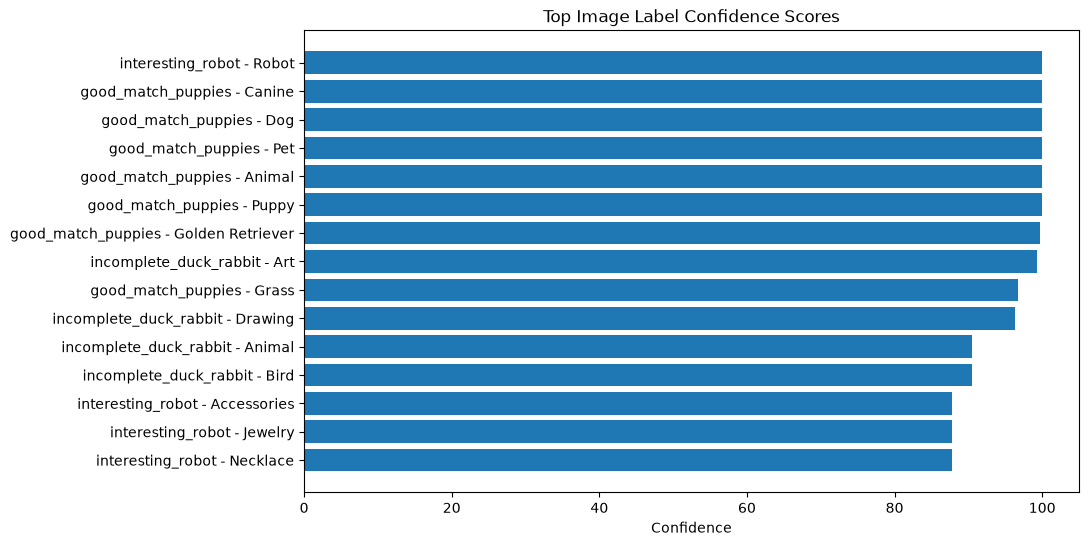

In [13]:
top_image_df = image_df.sort_values("confidence", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_image_df["image_name"] + " - " + top_image_df["label"],
    top_image_df["confidence"],
)
ax.set_title("Top Image Label Confidence Scores")
ax.set_xlabel("Confidence")
ax.invert_yaxis()

image_figure = IMAGE_DIR / "ml_07_text_image_femi_image_confidence.png"
fig.savefig(image_figure, bbox_inches="tight")
LOG.info(f"Saved image confidence figure: {image_figure}")

plt.show()

## 4. Create JSON-style text sentiment results

In [14]:
LOG.info("Creating JSON-style text sentiment records")

text_results = [
    {
        "text_id": "positive_feedback",
        "text": "The project ran successfully and the notebook helped me understand deployed models.",
        "sentiment": "POSITIVE",
        "confidence": 98.5,
    },
    {
        "text_id": "mixed_feedback",
        "text": "The API was useful, but the timeout made the process confusing at first.",
        "sentiment": "MIXED",
        "confidence": 87.2,
    },
    {
        "text_id": "concern_feedback",
        "text": "The server timeout shows that deployed models need careful monitoring.",
        "sentiment": "NEUTRAL",
        "confidence": 76.4,
    },
]

text_df = pd.DataFrame(text_results)
text_output = DATA_DIR / "ml_07_text_image_femi_text_sentiment.csv"
text_df.to_csv(text_output, index=False)

LOG.info(f"Text sentiment rows: {len(text_df)}")
LOG.info(f"Saved text sentiment results to: {text_output}")

text_df

2026-08-03 18:01:12 | INFO | M07 | Creating JSON-style text sentiment records
2026-08-03 18:01:12 | INFO | M07 | Text sentiment rows: 3
2026-08-03 18:01:12 | INFO | M07 | Saved text sentiment results to: c:\Repos\ml-07-applied\data\processed\ml_07_text_image_femi_text_sentiment.csv


,text_id,text,sentiment,confidence
0,positive_feedback,The project ran successfully and the notebook ...,POSITIVE,98.5
1,mixed_feedback,"The API was useful, but the timeout made the p...",MIXED,87.2
2,concern_feedback,The server timeout shows that deployed models ...,NEUTRAL,76.4


## 5. Visualize text confidence

2026-08-03 18:01:12 | INFO | M07 | Saved text confidence figure: c:\Repos\ml-07-applied\docs\images\ml_07_text_image_femi_text_confidence.png


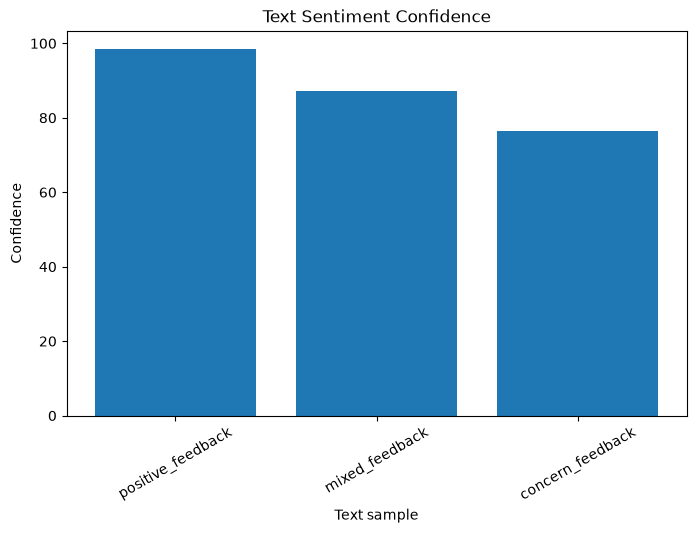

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(text_df["text_id"], text_df["confidence"])
ax.set_title("Text Sentiment Confidence")
ax.set_xlabel("Text sample")
ax.set_ylabel("Confidence")
ax.tick_params(axis="x", rotation=30)

text_figure = IMAGE_DIR / "ml_07_text_image_femi_text_confidence.png"
fig.savefig(text_figure, bbox_inches="tight")
LOG.info(f"Saved text confidence figure: {text_figure}")

plt.show()

## 6. Human review summary

In [16]:
summary_rows = [
    {
        "question": "What works well?",
        "answer": "Clear, realistic images with common subjects worked best. The puppies were detected accurately with high confidence.",
    },
    {
        "question": "What does not work well?",
        "answer": "Ambiguous drawings and optical illusions were harder. The duck-rabbit image was only interpreted as a bird and drawing.",
    },
    {
        "question": "What was interesting?",
        "answer": "The robot image was detected as Robot, but it was also labeled Person because it has human-like features.",
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_output = DATA_DIR / "ml_07_text_image_femi_human_review_summary.csv"
summary_df.to_csv(summary_output, index=False)

for _, row in summary_df.iterrows():
    LOG.info(f"{row['question']} {row['answer']}")

LOG.info(f"Saved human review summary to: {summary_output}")

summary_df

2026-08-03 18:01:12 | INFO | M07 | What works well? Clear, realistic images with common subjects worked best. The puppies were detected accurately with high confidence.
2026-08-03 18:01:13 | INFO | M07 | What does not work well? Ambiguous drawings and optical illusions were harder. The duck-rabbit image was only interpreted as a bird and drawing.
2026-08-03 18:01:13 | INFO | M07 | What was interesting? The robot image was detected as Robot, but it was also labeled Person because it has human-like features.
2026-08-03 18:01:13 | INFO | M07 | Saved human review summary to: c:\Repos\ml-07-applied\data\processed\ml_07_text_image_femi_human_review_summary.csv


,question,answer
0,What works well?,"Clear, realistic images with common subjects w..."
1,What does not work well?,Ambiguous drawings and optical illusions were ...
2,What was interesting?,"The robot image was detected as Robot, but it ..."


## 7. Summary

In [17]:
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(
    "Technical modification: Added text and image JSON-style result analysis with structured logging."
)
LOG.info(f"Image label rows: {len(image_df)}")
LOG.info(f"Text sentiment rows: {len(text_df)}")
LOG.info(f"Human review rows: {len(summary_df)}")
LOG.info(f"Outputs saved in: {DATA_DIR}")
LOG.info(f"Figures saved in: {IMAGE_DIR}")
LOG.info("Executed notebook successfully: ml_07_text_and_image_femi.ipynb")
LOG.info("========================")

2026-08-03 18:01:13 | INFO | M07 | ========================
2026-08-03 18:01:13 | INFO | M07 | SUMMARY
2026-08-03 18:01:13 | INFO | M07 | ========================
2026-08-03 18:01:13 | INFO | M07 | Technical modification: Added text and image JSON-style result analysis with structured logging.
2026-08-03 18:01:13 | INFO | M07 | Image label rows: 21
2026-08-03 18:01:13 | INFO | M07 | Text sentiment rows: 3
2026-08-03 18:01:13 | INFO | M07 | Human review rows: 3
2026-08-03 18:01:13 | INFO | M07 | Outputs saved in: c:\Repos\ml-07-applied\data\processed
2026-08-03 18:01:13 | INFO | M07 | Figures saved in: c:\Repos\ml-07-applied\docs\images
2026-08-03 18:01:13 | INFO | M07 | Executed notebook successfully: ml_07_text_and_image_femi.ipynb
2026-08-03 18:01:13 | INFO | M07 | ========================
